###### pie charts 
<div style='font-size:14px'>we will not only discuss how to plot pie charts but we'll also see when are the scenarios to use these visuals

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Text(0, 0.5, '')

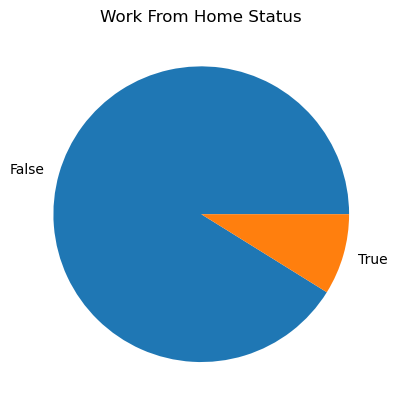

In [6]:
df['job_work_from_home'].value_counts().plot(kind='pie')
plt.title('Work From Home Status')
plt.ylabel('')

Text(0, 0.5, '')

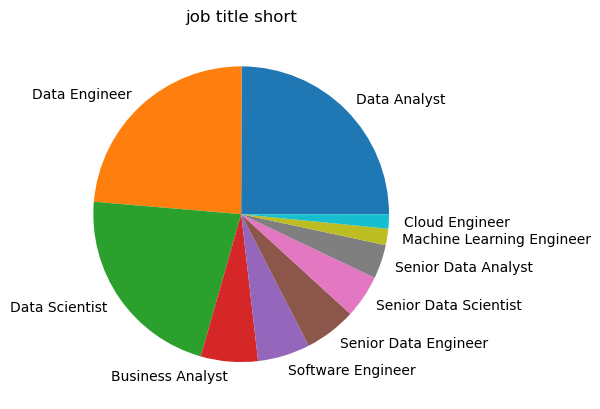

In [7]:
df['job_title_short'].value_counts().plot(kind='pie')
plt.title('job title short')
plt.ylabel('')

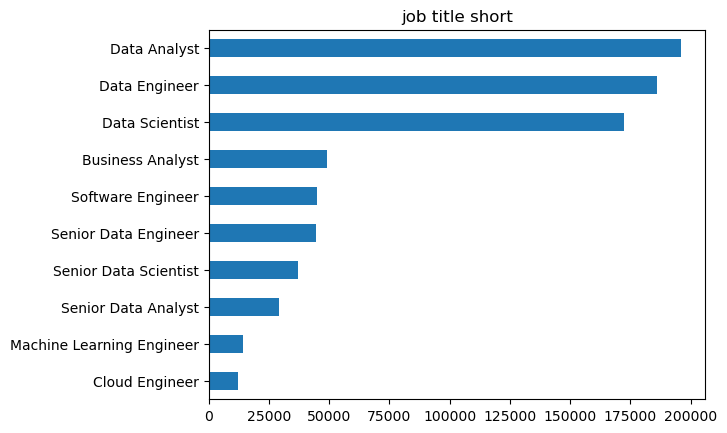

In [9]:
df['job_title_short'].value_counts().plot(kind='barh')
plt.title('job title short')
plt.ylabel('')
plt.gca().invert_yaxis()

<div style='font-size:14px'>now if we see compare to bar chart pie chart is more difficult to understand in job title short data so we need to be very particular when to use which type

##
now on this pie chart there are two things we need to customise on this first is the starting angle where our pie chart strt this should be mentioned so we will use strtangle to tell the strting angle and the other thing we want is the percentages outlining what the true values are and wt the false values are. So for this we will use autopct i.e auto percentage

Text(0, 0.5, '')

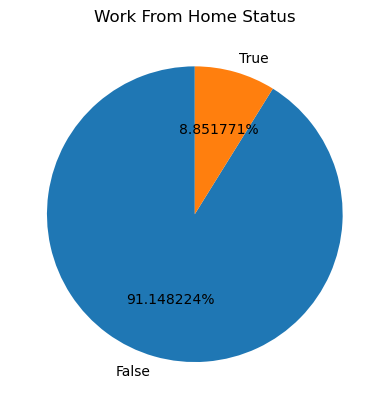

In [27]:
df['job_work_from_home'].value_counts().plot(kind='pie',startangle=90,autopct='%1f%%') #here if we write %1.1f that means i decimal space after .
plt.title('Work From Home Status')
plt.ylabel('')

now we will integerate subplot in pie charts

In [29]:
df[['job_work_from_home','job_no_degree_mention','job_health_insurance']]

,job_work_from_home,job_no_degree_mention,job_health_insurance
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
785736,False,False,False
785737,False,False,False
785738,False,False,False
785739,False,False,False


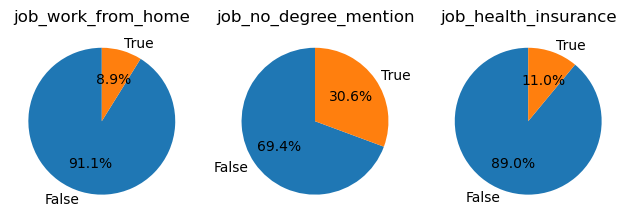

In [39]:
items=['job_work_from_home','job_no_degree_mention','job_health_insurance']
fig, ax = plt.subplots(1,3)

for i, item in enumerate(items):
    df[item].value_counts().plot(kind='pie',ax=ax[i],title=item,startangle=90, autopct='%1.1f%%')
    ax[i].set_ylabel('')

fig.tight_layout()

<div style='font-size:14px'>this upper one is done using pandas but plotting through matplotlib will be like the below one

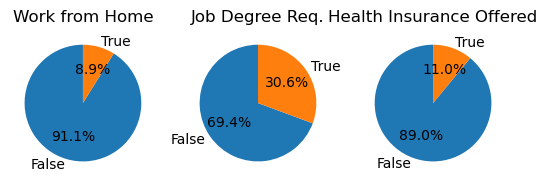

In [40]:
fig, ax = plt.subplots(1,3)

dict_column = {
'job_work_from_home': 'Work from Home',
'job_no_degree_mention': 'Job Degree Req.',
'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), startangle=90, autopct='%1.1f%%',labels=['False','True'])
    ax[i].set_title(title)
plt.show()